# Environment setup

## Load code

In [1]:
!git clone https://github.com/sofi12321/RL_rover_delivery.git

Cloning into 'RL_rover_delivery'...
remote: Enumerating objects: 153, done.
remote: Counting objects: 100% (153/153), done.
remote: Compressing objects: 100% (145/145), done.
remote: Total 153 (delta 59), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (153/153), 5.50 MiB | 13.41 MiB/s, done.
Resolving deltas: 100% (59/59), done.


In [2]:
%cd RL_rover_delivery

/content/RL_rover_delivery


In [3]:
# Add code to the path
import os
import sys

project_path = './'

# Add path to the project in sys.path
sys.path.insert(0, os.path.abspath(project_path))
print("Current PYTHONPATH:", sys.path[0])

Current PYTHONPATH: /content/RL_rover_delivery


## Install requirenments

In [4]:
!pip -q install gymnasium matplotlib numpy pandas pyyaml torch stable-baselines3 tqdm pytest

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.5/187.5 kB 4.7 MB/s eta 0:00:00


In [5]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import warnings
warnings.filterwarnings("ignore")

%matplotlib inline

## Change config, if needed

In [6]:
from utils.config import load_config, Config

In [7]:
# If you want to run training without lower number of parameters,
# you can use default config
# base_config = Config('./configs/default.yaml')

# Change parameters in the configs/fast_example.yaml
base_config = Config('./configs/fast_example.yaml')


print("Current configuration:")
print(f"Device: {base_config.device}")
print(f"Total timesteps: {base_config.training.total_timesteps}")
base_config

Current configuration:
Device: cpu
Total timesteps: 200


Config({'environment': {'field_size': [20, 20], 'max_steps': 1000, 'dt': 0.1, 'robot_radius': 0.5, 'goal_radius': 1.5, 'min_obstacles': 2, 'max_obstacles': 4, 'obstacle_radius_range': [1, 2], 'init_position': 'random', 'goal_position': 'random', 'sensor_range': 5.0, 'reward_weights': {'progress': 1.0, 'collision': 100.0, 'steer': 0.1, 'speed': 0.01, 'goal': 500.0, 'time': 0.1}, 'max_speed': 1.0, 'max_steer': 0.5}, 'training': {'buffer_size': 200, 'batch_size': 200, 'gamma': 0.99, 'tau': 0.005, 'lr': 0.0003, 'alpha': 'auto', 'target_entropy': 'auto', 'total_timesteps': 200, 'eval_freq': 50, 'eval_episodes': 20}, 'device': 'cpu'})

## Check environment

In [8]:
from env.rover_env import RoversEnv
from env.render import render_env

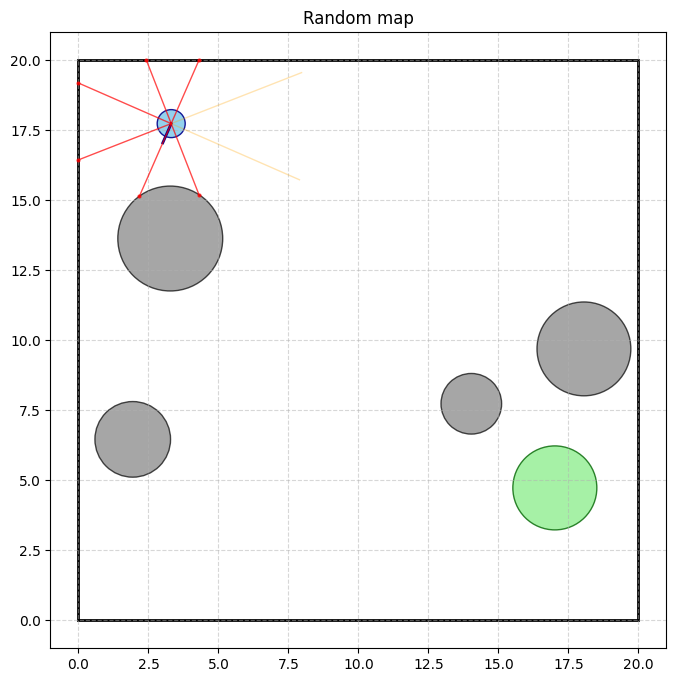

In [9]:
# Visualization of one random map
env_demo = RoversEnv(base_config)
obs, info = env_demo.reset(seed=12)
fig = render_env(env_demo, show_sensors=True, title="Random map")
plt.show()

# Algorithm implementation

In [10]:
# See code in github for details of implementation
from sac_custom.agent import SACAgent

# Training process

Training of SAC tooks around 6-7 hours for 1.000.000 timestamps, so we have  trained both our custom realisation and baseline realisation before to show, what they could achieve. We named that step "pretraining". After that we show the process for 100 additional timesteps to show that algorithms indeed work.

If you wish to run full pipeline without our pretrained weights, just increase total_timesteps and do not load weights before training to the agents.

## Custom agent

### Train custom agent from scratch

In [11]:
from training.train_custom import train_custom

In [22]:
custom_env = RoversEnv(base_config)
custom_agent = SACAgent(obs_dim=13, action_dim=2, config=base_config)

In [23]:
print("Start training of custom agent...")
train_custom(custom_env, custom_agent, base_config, log_dir='results/custom_run')

Start training of custom agent...
Step 50: avg_reward=-119.05, success_rate=0.05
Step 100: avg_reward=-108.46, success_rate=0.05
Step 150: avg_reward=-100.22, success_rate=0.05
Step 200: avg_reward=-85.30, success_rate=0.10
Training finished. Final model saved to results/custom_run/models/final.pt


In [24]:
# Load final weights after training
custom_agent.load_checkpoint("./results/custom_run/models/final.pt")

### Load pretrained agent

In [15]:
# If agent was pretrained, you can load its weights
pretrained_custom_agent = SACAgent(obs_dim=13, action_dim=2, config=base_config)
pretrained_custom_agent.load_checkpoint("./results/custom_run/pretrained_final.pt")

## Baseline agent

Baseline agent means realisation of SAC from stable_baselines3.

### Train baseline agent from scratch

In [16]:
from baseline.baseline_agent import BaselineSACAgent
from training.train_baseline import train_baseline

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [17]:
baseline_env = RoversEnv(base_config)
baseline_agent = BaselineSACAgent(baseline_env, base_config)

In [18]:
print("Start training of baseline agent...")
train_baseline(baseline_env, baseline_agent, base_config, log_dir='results/baseline_run')

Start training of baseline agent...
Step 50: avg_reward=-0.89, success_rate=0.20
Step 100: avg_reward=-100.29, success_rate=0.05
Step 150: avg_reward=-39.78, success_rate=0.15
Step 200: avg_reward=-72.75, success_rate=0.10
Training finished. Final model saved to results/baseline_run/models/final.zip


In [19]:
# Load final weights after training
baseline_agent.load("./results/baseline_run/models/final.zip")

### Load pretrained agent

In [21]:
# If agent was pretrained, you can load its weights
pretrained_baseline_agent = BaselineSACAgent(baseline_env, base_config)
pretrained_baseline_agent.load("./results/baseline_run/pretrained_final.zip")

# Results and visualisation

## Final evaluation

Lets evaluate our agent and baseline agent on the same episodes

In [25]:
from evaluation.compare import compare_agents

In [26]:
compare_env = RoversEnv(base_config)
print("Comparison of pretrained agents")
agents = {
    'baseline': pretrained_custom_agent,
    'custom': pretrained_baseline_agent
}
df_compare = compare_agents(compare_env, agents, num_episodes=50, seed=42)
print(df_compare.groupby('agent')[['reward', 'success']].mean())

Comparison of pretrained agents
              reward  success
agent                        
baseline  456.976533     0.94
custom    441.784662     0.92


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [27]:
print("Comparison of agents trained now on small number of timestamps")
agents = {
    'baseline': custom_agent,
    'custom': baseline_agent
}
df_compare = compare_agents(compare_env, agents, num_episodes=50, seed=42)
print(df_compare.groupby('agent')[['reward', 'success']].mean())

Comparison of agents trained now on small number of timestamps
              reward  success
agent                        
baseline -117.859345     0.06
custom   -109.144633     0.04


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## Learning curves

In [28]:
from visualization.plot_results import plot_learning_curves

### Plot of pretraining results

We run algorithm for 1.000.000 timestams and show here results of evaluation on 20 episodes made after every 10.000 training timestemps.

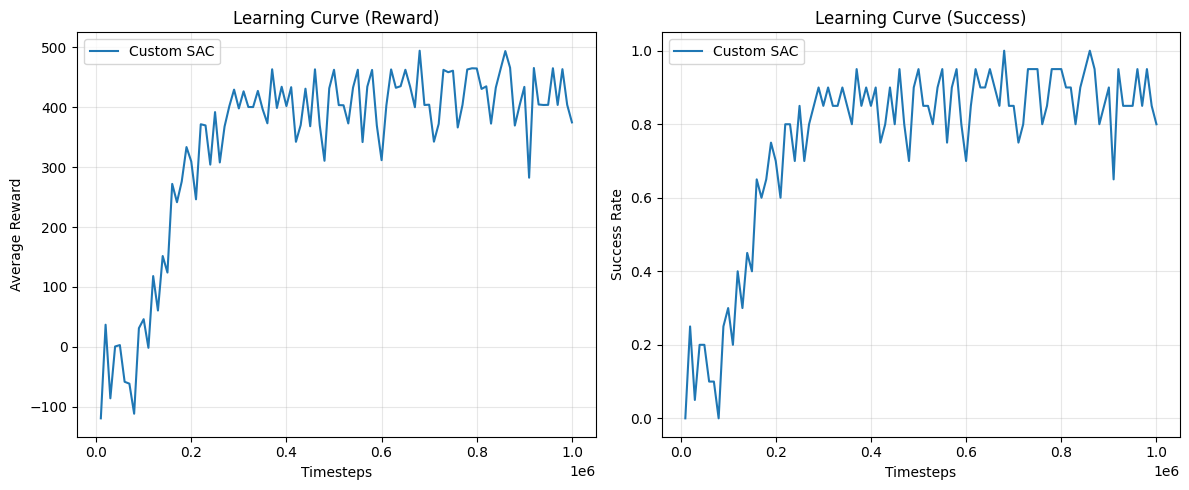

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [29]:
import pandas as pd

custom_log = './results/custom_run/pretrained_progress.csv'

plot_learning_curves([custom_log],
                    labels=['Custom SAC'],
                    save_path='./results/plots/pretrained_learning_curve.png',
                    sliding_window=None)
plt.show()

### Plot of pretraining results with sliding window

Here we show training curve both for our implementation and baseline implementation. To look on the general learning curve and overcome noise we make a sliding window

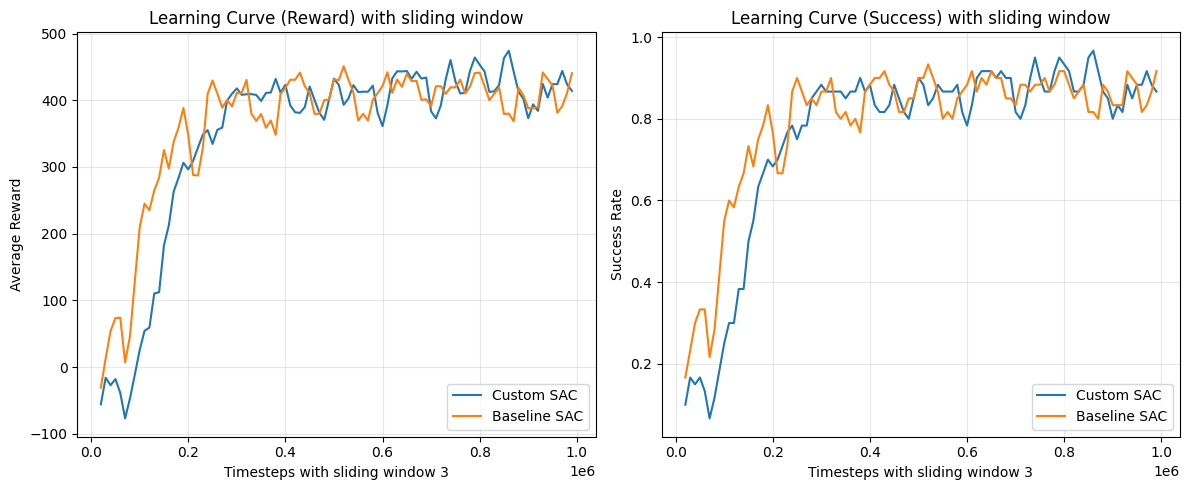

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [30]:
custom_log = './results/custom_run/pretrained_progress.csv'
baseline_log = './results/baseline_run/pretrained_progress.csv'

plot_learning_curves([custom_log, baseline_log],
                    labels=['Custom SAC', 'Baseline SAC'],
                    save_path='./results/plots/pretrained_comparison_sliding.png',
                    sliding_window=3)
plt.show()

### Plot of pretraining results with sliding window

Now lets look on the learning curve done in the current run

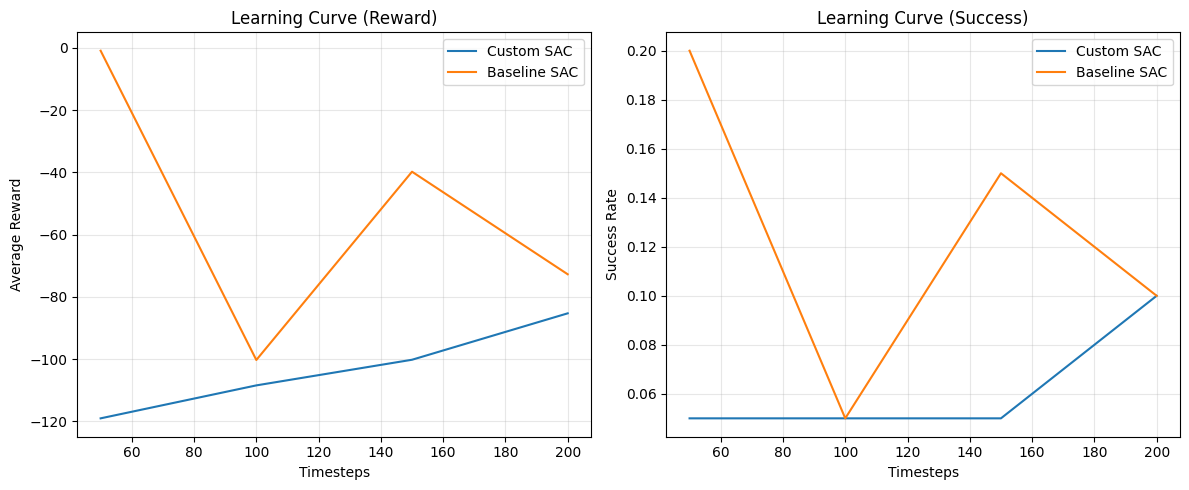

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [31]:
custom_log = './results/custom_run/progress.csv'
baseline_log = './results/baseline_run/progress.csv'

plot_learning_curves([custom_log, baseline_log],
                    labels=['Custom SAC', 'Baseline SAC'],
                    save_path='./results/plots/comparison.png',
                    sliding_window=None)
plt.show()

## Video comparison

We run both our agent and baseline agent on the same environment and visualize their results in a video. Please download `results/videos/comparison.mp4` to watch the resulting video

In [32]:
# If you don't have ffmpeg, try to uncomment and run the following
# !pip install ffmpeg
# !apt-get install -y ffmpeg

In [ ]:
from visualization.side_by_side import create_comparison_video

compare_env = RoversEnv(base_config)

# Создадим короткое видео для наглядности
create_comparison_video(compare_env, baseline_agent, custom_agent,
                        num_steps=300, agent_names=['Baseline', 'Custom'],
                        save_path='./results/videos/comparison.mp4', seed=12)
print("Video was saved to rovers-sac/results/videos/comparison.mp4")

In [ ]:
from visualization.side_by_side import create_comparison_video

compare_env = RoversEnv(base_config)

# Создадим короткое видео для наглядности
create_comparison_video(compare_env, pretrained_baseline_agent, pretrained_custom_agent,
                        num_steps=500, agent_names=['Baseline', 'Custom'],
                        save_path='./results/videos/pretrained_comparison.mp4', seed=12)
print("Video was saved to results/videos/pretrained_comparison.mp4")